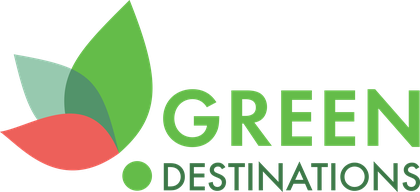

# Green Destinations — Employee Attrition Analysis

**Project Brief:** Green Destinations' HR Director has noticed an increase in attrition and wants to know:
1. What is the attrition rate?
2. Do factors like **age**, **years at the company**, and **income** play a part in whether people leave?

Dataset: employee survey data — 1,470 employees, 35 fields (demographics, compensation, satisfaction scores, tenure).

## 1. Setup & Load Data

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
%matplotlib inline
sns.set(color_codes=True)
import warnings
warnings.filterwarnings("ignore")

In [1]:
df = pd.read_csv('Green_Destinations.csv', encoding='utf-8-sig')
df.head()

   Age Attrition     BusinessTravel  DailyRate              Department  DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  EnvironmentSatisfaction  Gender  HourlyRate  JobInvolvement  JobLevel                JobRole  JobSatisfaction MaritalStatus  MonthlyIncome  MonthlyRate  NumCompaniesWorked Over18 OverTime  PercentSalaryHike  PerformanceRating  RelationshipSatisfaction  StandardHours  StockOptionLevel  TotalWorkingYears  TrainingTimesLastYear  WorkLifeBalance  YearsAtCompany  YearsInCurrentRole  YearsSinceLastPromotion  YearsWithCurrManager
0   41       Yes      Travel_Rarely       1102                   Sales                 1          2  Life Sciences              1               1                        2  Female          94               3         2        Sales Executive                4        Single           5993        19479                   8      Y      Yes                 11                  3                         1             80             

## 2. Basic Structure & Data Quality

In [1]:
df.shape

(1470, 35)

In [1]:
df.isnull().sum().sum()

0

In [1]:
df.duplicated().sum()

0

No missing values, no duplicates. Three columns (`EmployeeCount`, `StandardHours`, `Over18`) have a single constant value across every row, so they carry no analytical signal and are excluded from further analysis.

In [1]:
[c for c in df.columns if df[c].nunique() == 1]

['EmployeeCount', 'Over18', 'StandardHours']

## 3. Question 1 — What is the Attrition Rate?

In [1]:
attrition_counts = df['Attrition'].value_counts()
attrition_rate = (df['Attrition'] == 'Yes').mean()

print(f"Attrition Rate: {attrition_rate:.2%}")
print(f"Employees who left: {attrition_counts['Yes']}")
print(f"Employees who stayed: {attrition_counts['No']}")
print(f"Total employees: {len(df)}")

Attrition Rate: 16.12%
Employees who left: 237
Employees who stayed: 1233
Total employees: 1470

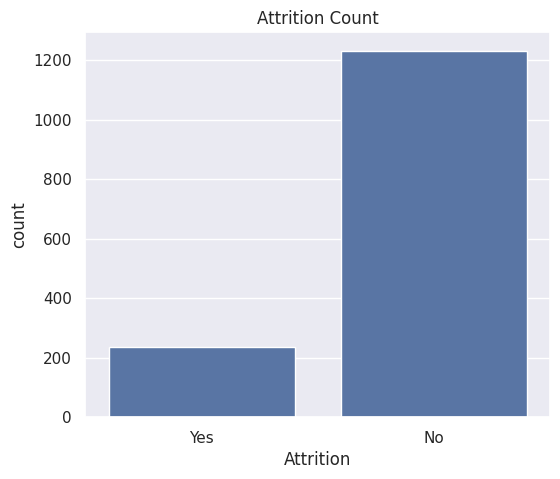

In [1]:
plt.figure(figsize=(6,5))
sns.countplot(x='Attrition', data=df)
plt.title('Attrition Count')
plt.show()

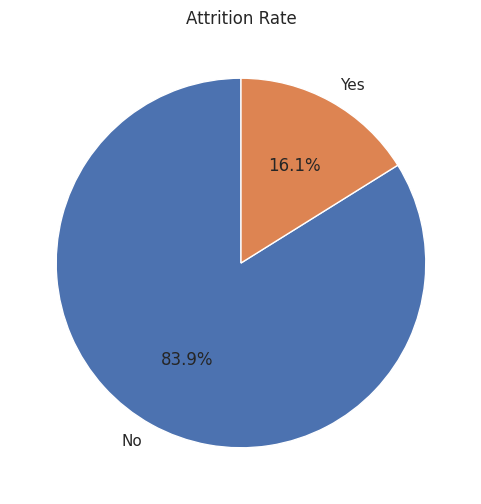

In [1]:
plt.figure(figsize=(6,6))
attrition_counts.plot(kind='pie', autopct='%1.1f%%', colors=['#4C72B0','#DD8452'], startangle=90)
plt.title('Attrition Rate')
plt.ylabel('')
plt.show()

**Answer: the attrition rate is 16.12%** — 237 of 1,470 employees have left.

## 4. Question 2 — Does Age Play a Part?

In [1]:
age_stats = df.groupby('Attrition')['Age'].agg(['mean','median','std'])
age_stats

                mean  median      std
Attrition                            
No         37.561233    36.0  8.88836
Yes        33.607595    32.0  9.68935

In [1]:
age_yes = df[df['Attrition']=='Yes']['Age']
age_no = df[df['Attrition']=='No']['Age']
t_age, p_age = stats.ttest_ind(age_yes, age_no, equal_var=False)

print(f"t-statistic = {t_age:.4f}")
print(f"p-value = {p_age:.6f}")
print(f"Significant at alpha=0.05: {p_age < 0.05}")

t-statistic = -5.8280
p-value = 0.000000
Significant at alpha=0.05: True

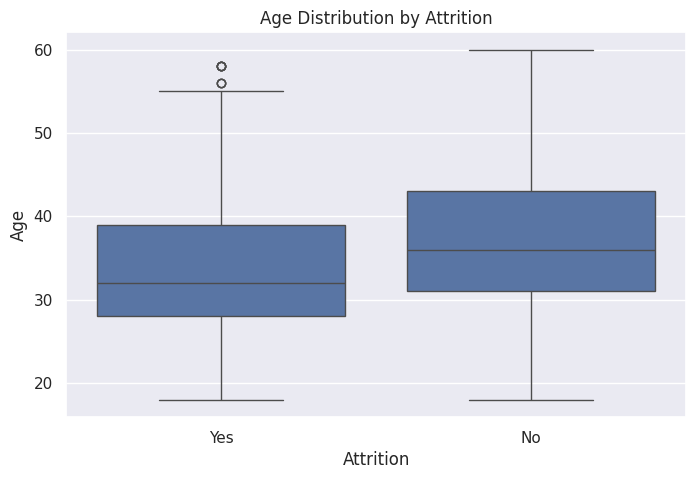

In [1]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Attrition', y='Age', data=df)
plt.title('Age Distribution by Attrition')
plt.show()

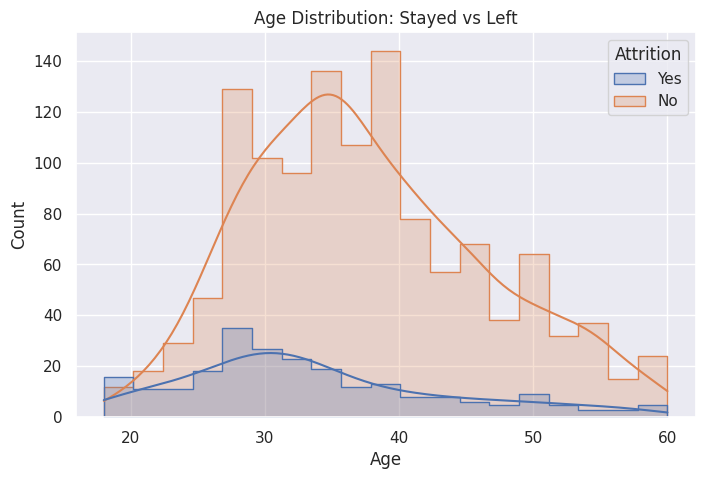

In [1]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='Age', hue='Attrition', kde=True, element='step')
plt.title('Age Distribution: Stayed vs Left')
plt.show()

**Yes — age matters.** Employees who left are on average noticeably younger (mean ~33.6 vs ~37.6 for those who stayed), and a two-sample t-test confirms this difference is statistically significant (p < 0.001).

## 5. Question 3 — Does Years at the Company Play a Part?

In [1]:
tenure_stats = df.groupby('Attrition')['YearsAtCompany'].agg(['mean','median','std'])
tenure_stats

               mean  median       std
Attrition                            
No         7.369019     6.0  6.096298
Yes        5.130802     3.0  5.949984

In [1]:
tenure_yes = df[df['Attrition']=='Yes']['YearsAtCompany']
tenure_no = df[df['Attrition']=='No']['YearsAtCompany']
t_ten, p_ten = stats.ttest_ind(tenure_yes, tenure_no, equal_var=False)

print(f"t-statistic = {t_ten:.4f}")
print(f"p-value = {p_ten:.6f}")
print(f"Significant at alpha=0.05: {p_ten < 0.05}")

t-statistic = -5.2826
p-value = 0.000000
Significant at alpha=0.05: True

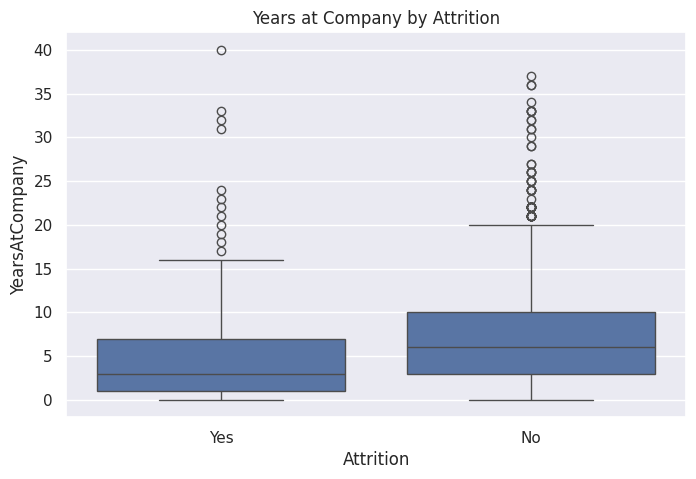

In [1]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Attrition', y='YearsAtCompany', data=df)
plt.title('Years at Company by Attrition')
plt.show()

In [1]:
df['Tenure_Bucket'] = pd.cut(df['YearsAtCompany'], bins=[-1,1,3,5,10,50], labels=['0-1','2-3','4-5','6-10','10+'])
tenure_bucket_rate = df.groupby('Tenure_Bucket')['Attrition'].apply(lambda x: (x=='Yes').mean())
tenure_bucket_rate

Tenure_Bucket
0-1     0.348837
2-3     0.184314
4-5     0.130719
6-10    0.122768
10+     0.081301

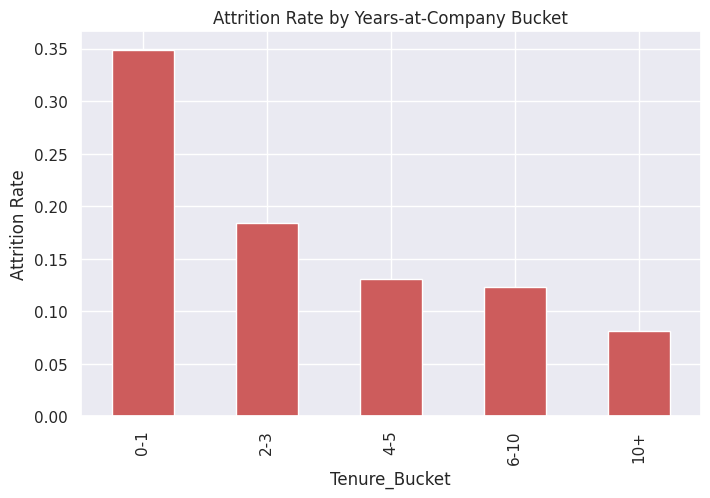

In [1]:
plt.figure(figsize=(8,5))
tenure_bucket_rate.plot(kind='bar', color='indianred')
plt.title('Attrition Rate by Years-at-Company Bucket')
plt.ylabel('Attrition Rate')
plt.show()

**Yes — tenure matters.** Attrition is heavily concentrated in the earliest years: employees with 0-1 years at the company leave at a much higher rate than long-tenured employees, and the difference in mean tenure between leavers and stayers is statistically significant (p < 0.001).

## 6. Question 4 — Does Income Play a Part?

In [1]:
income_stats = df.groupby('Attrition')['MonthlyIncome'].agg(['mean','median','std'])
income_stats

                  mean  median          std
Attrition                                  
No         6832.739659  5204.0  4818.208001
Yes        4787.092827  3202.0  3640.210367

In [1]:
income_yes = df[df['Attrition']=='Yes']['MonthlyIncome']
income_no = df[df['Attrition']=='No']['MonthlyIncome']
t_inc, p_inc = stats.ttest_ind(income_yes, income_no, equal_var=False)

print(f"t-statistic = {t_inc:.4f}")
print(f"p-value = {p_inc:.6f}")
print(f"Significant at alpha=0.05: {p_inc < 0.05}")

t-statistic = -7.4826
p-value = 0.000000
Significant at alpha=0.05: True

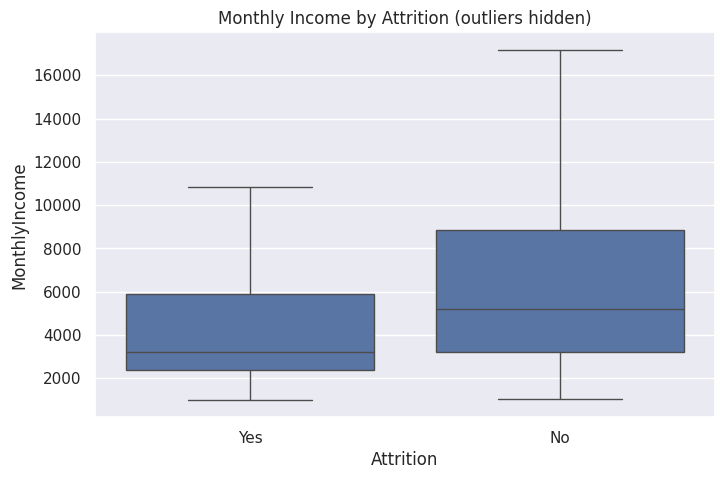

In [1]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Attrition', y='MonthlyIncome', data=df, showfliers=False)
plt.title('Monthly Income by Attrition (outliers hidden)')
plt.show()

In [1]:
df['Income_Quartile'] = pd.qcut(df['MonthlyIncome'], 4, labels=['Q1 (lowest)','Q2','Q3','Q4 (highest)'])
income_q_rate = df.groupby('Income_Quartile')['Attrition'].apply(lambda x: (x=='Yes').mean())
income_q_rate

Income_Quartile
Q1 (lowest)     0.292683
Q2              0.142077
Q3              0.106267
Q4 (highest)    0.103261

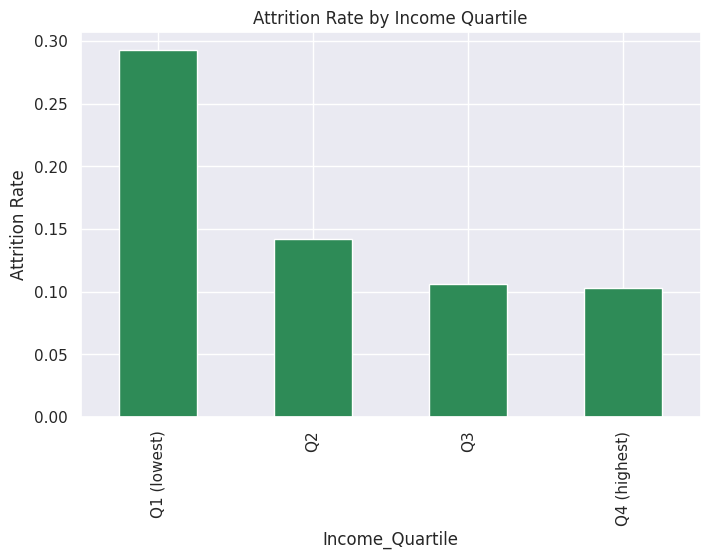

In [1]:
plt.figure(figsize=(8,5))
income_q_rate.plot(kind='bar', color='seagreen')
plt.title('Attrition Rate by Income Quartile')
plt.ylabel('Attrition Rate')
plt.show()

**Yes — income matters, strongly.** The lowest income quartile leaves at a dramatically higher rate than the highest quartile, and this is the most statistically significant of the three factors tested (p < 0.001, largest t-statistic in magnitude).

## 7. Combined View

In [1]:
df['Attrition_num'] = (df['Attrition']=='Yes').astype(int)
corr_cols = ['Age','YearsAtCompany','MonthlyIncome','Attrition_num']
corr = df[corr_cols].corr()
corr

                     Age  YearsAtCompany  MonthlyIncome  Attrition_num
Age             1.000000        0.311309       0.497855      -0.159205
YearsAtCompany  0.311309        1.000000       0.514285      -0.134392
MonthlyIncome   0.497855        0.514285       1.000000      -0.159840
Attrition_num  -0.159205       -0.134392      -0.159840       1.000000

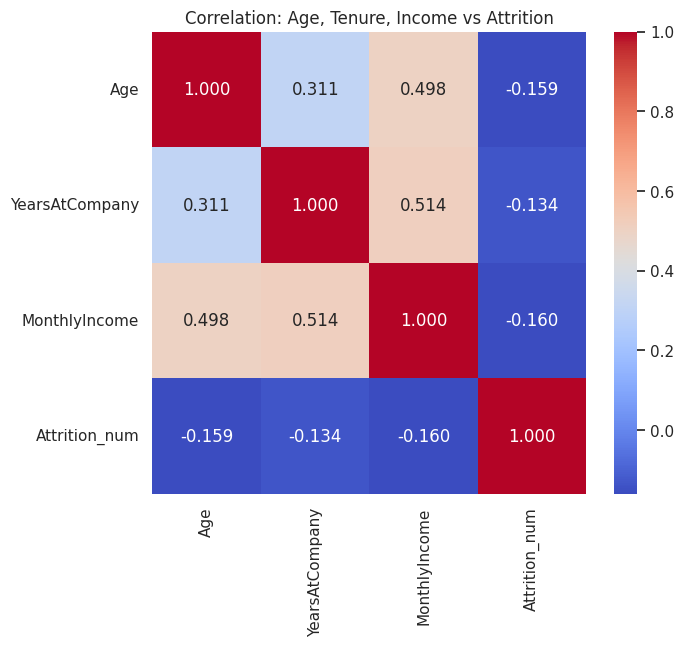

In [1]:
plt.figure(figsize=(7,6))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm')
plt.title('Correlation: Age, Tenure, Income vs Attrition')
plt.show()

## 8. Additional Context (Beyond the Original Brief)

Two more factors stood out strongly enough while exploring this data that they're worth flagging to the HR Director, even though they weren't in the original question list.

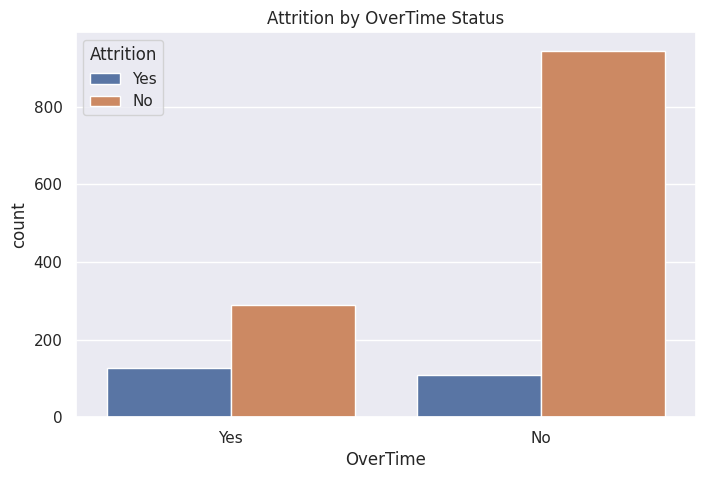

In [1]:
plt.figure(figsize=(8,5))
sns.countplot(x='OverTime', hue='Attrition', data=df)
plt.title('Attrition by OverTime Status')
plt.show()

In [1]:
overtime_rate = df.groupby('OverTime')['Attrition'].apply(lambda x: (x=='Yes').mean())
overtime_rate

OverTime
No     0.104364
Yes    0.305288

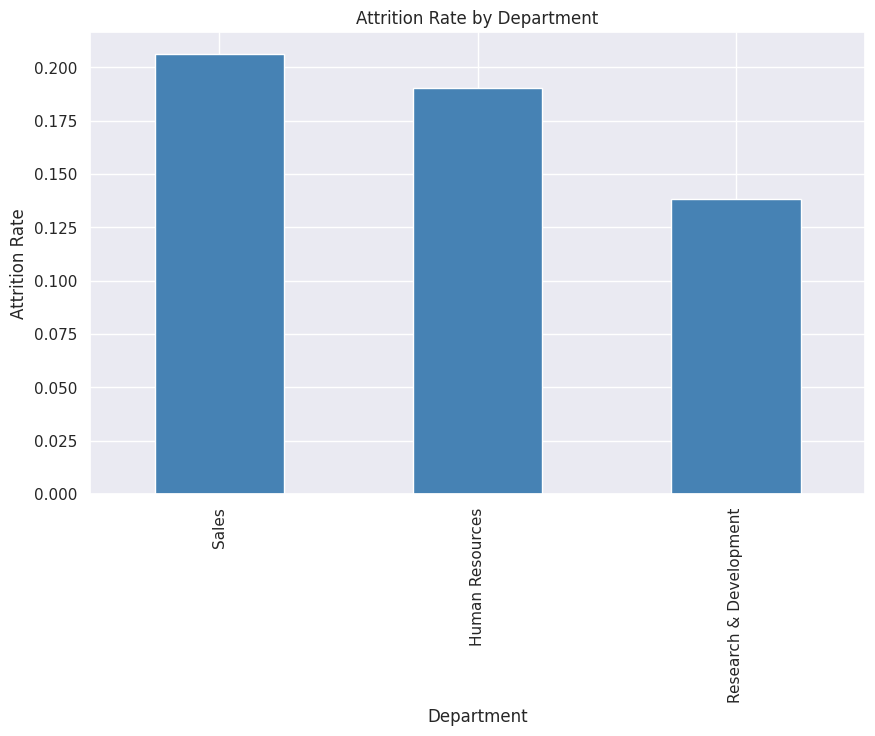

In [1]:
plt.figure(figsize=(10,6))
dept_rate = df.groupby('Department')['Attrition'].apply(lambda x: (x=='Yes').mean()).sort_values(ascending=False)
dept_rate.plot(kind='bar', color='steelblue')
plt.title('Attrition Rate by Department')
plt.ylabel('Attrition Rate')
plt.show()

**OverTime is the single strongest attrition signal found in this dataset** — employees who regularly work overtime leave at roughly 3x the rate of those who don't. **Sales** also has a notably higher attrition rate than the other departments.

## 9. Summary — Answers for the HR Director

1. **Attrition rate: 16.12%** (237 of 1,470 employees have left).
2. **Age plays a part**: leavers are on average younger (~33.6 vs ~37.6 years), a statistically significant difference (p < 0.001).
3. **Years at the company plays a part**: attrition is concentrated in employees' early tenure (0-1 years), and drops off sharply the longer someone stays (p < 0.001).
4. **Income plays a part** — the strongest of the three factors tested: the lowest income quartile leaves at a much higher rate than the highest quartile (p < 0.001).
5. **Bonus finding**: OverTime status is an even stronger signal than any of the three original factors — employees working overtime leave at roughly 3x the rate of those who don't, and this is worth a follow-up conversation with the HR Director, since it may be a more actionable lever than age or tenure.